In [1]:
import pandas as pd
import numpy as np

fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

fraud_df["signup_time"] = pd.to_datetime(fraud_df["signup_time"])
fraud_df["purchase_time"] = pd.to_datetime(fraud_df["purchase_time"])

fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [2]:
fraud_df.shape

(151112, 11)

In [3]:
fraud_df["ip_address"] = fraud_df["ip_address"].astype(float)
ip_df["lower_bound_ip_address"] = ip_df["lower_bound_ip_address"].astype(float)
ip_df["upper_bound_ip_address"] = ip_df["upper_bound_ip_address"].astype(float)

def find_country(ip):
    matched_country = ip_df[
        (ip_df["lower_bound_ip_address"] <= ip) &
        (ip_df["upper_bound_ip_address"] >= ip)
    ]
    
    if len(matched_country) > 0:
        return matched_country.iloc[0]["country"]
    else:
        return "Unknown"

fraud_df["country"] = fraud_df["ip_address"].apply(find_country)

fraud_df[["ip_address", "country"]].head()

,ip_address,country
0,7.327584e+08,Japan
1,3.503114e+08,United States
2,2.621474e+09,United States
3,3.840542e+09,Unknown
4,4.155831e+08,United States


In [4]:
fraud_df["country"].isnull().sum()

np.int64(0)

In [5]:
fraud_df["hour_of_day"] = fraud_df["purchase_time"].dt.hour
fraud_df["day_of_week"] = fraud_df["purchase_time"].dt.dayofweek

fraud_df["time_since_signup"] = (
    fraud_df["purchase_time"] - fraud_df["signup_time"]
).dt.total_seconds() / 3600

fraud_df[["purchase_time", "hour_of_day", "day_of_week", "time_since_signup"]].head()

,purchase_time,hour_of_day,day_of_week,time_since_signup
0,2015-04-18 02:47:11,2,5,1251.856111
1,2015-06-08 01:38:54,1,0,4.984444
2,2015-01-01 18:52:45,18,3,0.000278
3,2015-05-04 13:54:50,13,0,136.690278
4,2015-09-09 18:40:53,18,2,1211.516944


In [6]:
user_transaction_count = fraud_df.groupby("user_id")["purchase_time"].count()
fraud_df["user_transaction_count"] = fraud_df["user_id"].map(user_transaction_count)

device_transaction_count = fraud_df.groupby("device_id")["purchase_time"].count()
fraud_df["device_transaction_count"] = fraud_df["device_id"].map(device_transaction_count)

fraud_df[["user_id", "device_id", "user_transaction_count", "device_transaction_count"]].head()

,user_id,device_id,user_transaction_count,device_transaction_count
0,22058,QVPSPJUOCKZAR,1,1
1,333320,EOGFQPIZPYXFZ,1,1
2,1359,YSSKYOSJHPPLJ,1,12
3,150084,ATGTXKYKUDUQN,1,1
4,221365,NAUITBZFJKHWW,1,1


In [7]:
fraud_df.to_csv("../data/processed/fraud_features.csv", index=False)

In [8]:
fraud_df["hour_of_day"] = fraud_df["purchase_time"].dt.hour
fraud_df["day_of_week"] = fraud_df["purchase_time"].dt.dayofweek

fraud_df["time_since_signup"] = (
    fraud_df["purchase_time"] - fraud_df["signup_time"]
).dt.total_seconds() / 3600

fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,country,hour_of_day,day_of_week,time_since_signup,user_transaction_count,device_transaction_count
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,Japan,2,5,1251.856111,1,1
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,United States,1,0,4.984444,1,1
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,United States,18,3,0.000278,1,12
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0,Unknown,13,0,136.690278,1,1
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0,United States,18,2,1211.516944,1,1


In [9]:
user_transaction_count = fraud_df.groupby("user_id")["purchase_time"].count()
fraud_df["user_transaction_count"] = fraud_df["user_id"].map(user_transaction_count)

fraud_df[["user_id", "user_transaction_count"]].head()

,user_id,user_transaction_count
0,22058,1
1,333320,1
2,1359,1
3,150084,1
4,221365,1


In [10]:
device_transaction_count = fraud_df.groupby("device_id")["purchase_time"].count()
fraud_df["device_transaction_count"] = fraud_df["device_id"].map(device_transaction_count)

fraud_df[["device_id", "device_transaction_count"]].head()

,device_id,device_transaction_count
0,QVPSPJUOCKZAR,1
1,EOGFQPIZPYXFZ,1
2,YSSKYOSJHPPLJ,12
3,ATGTXKYKUDUQN,1
4,NAUITBZFJKHWW,1


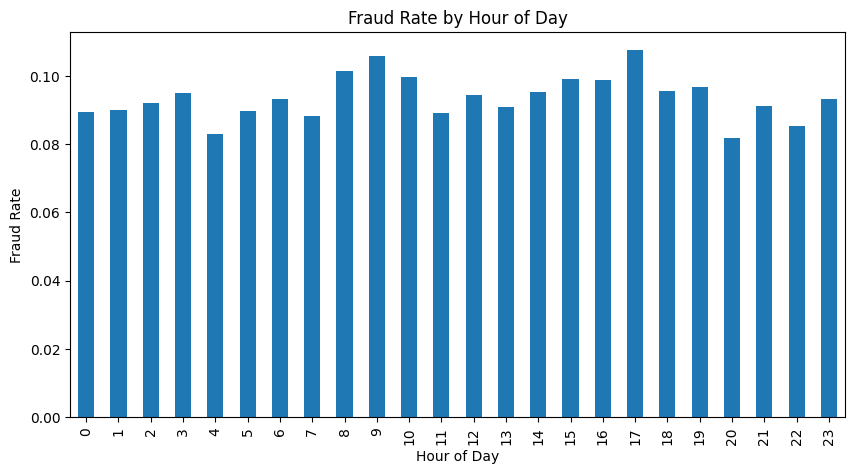

In [11]:
import matplotlib.pyplot as plt
hour_fraud = fraud_df.groupby("hour_of_day")["class"].mean()

hour_fraud.plot(kind="bar", figsize=(10,5))
plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.show()

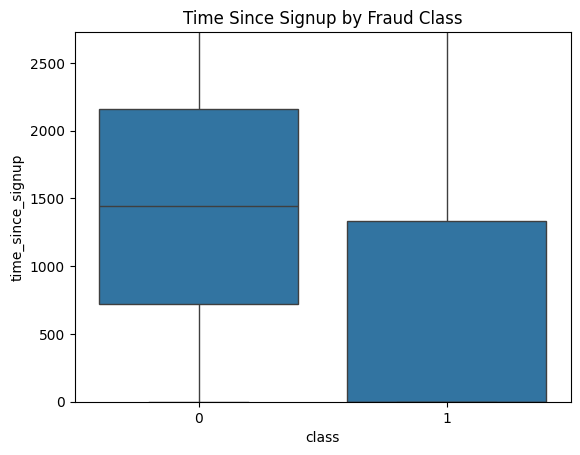

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=fraud_df, x="class", y="time_since_signup")
plt.title("Time Since Signup by Fraud Class")
plt.ylim(0, fraud_df["time_since_signup"].quantile(0.95))
plt.show()

In [13]:
fraud_df.to_csv("../data/processed/fraud_data_cleaned.csv", index=False)

In [14]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

fraud_df = pd.read_csv("../data/processed/fraud_data_cleaned.csv")
credit_df = pd.read_csv("../data/processed/creditcard_cleaned.csv")

In [15]:
fraud_model_df = fraud_df.drop(columns=[
    "user_id",
    "signup_time",
    "purchase_time",
    "device_id",
    "ip_address",
    "lower_bound_ip_address",
    "upper_bound_ip_address"
], errors="ignore")

In [16]:
fraud_model_df = pd.get_dummies(
    fraud_model_df,
    columns=["source", "browser", "sex", "country"],
    drop_first=True
)

In [17]:
X_fraud = fraud_model_df.drop("class", axis=1)
y_fraud = fraud_model_df["class"]

In [18]:
X_fraud_train, X_fraud_test, y_fraud_train, y_fraud_test = train_test_split(
    X_fraud,
    y_fraud,
    test_size=0.2,
    random_state=42,
    stratify=y_fraud
)

In [19]:
scaler = StandardScaler()

X_fraud_train_scaled = scaler.fit_transform(X_fraud_train)
X_fraud_test_scaled = scaler.transform(X_fraud_test)

In [20]:
smote = SMOTE(random_state=42)

X_fraud_train_resampled, y_fraud_train_resampled = smote.fit_resample(
    X_fraud_train_scaled,
    y_fraud_train
)

print("Before SMOTE:")
print(y_fraud_train.value_counts())

print("After SMOTE:")
print(pd.Series(y_fraud_train_resampled).value_counts())

Before SMOTE:
class
0    109568
1     11321
Name: count, dtype: int64
After SMOTE:
class
0    109568
1    109568
Name: count, dtype: int64


In [21]:
X_credit = credit_df.drop("Class", axis=1)
y_credit = credit_df["Class"]

X_credit_train, X_credit_test, y_credit_train, y_credit_test = train_test_split(
    X_credit,
    y_credit,
    test_size=0.2,
    random_state=42,
    stratify=y_credit
)

scaler = StandardScaler()

X_credit_train_scaled = scaler.fit_transform(X_credit_train)
X_credit_test_scaled = scaler.transform(X_credit_test)

smote = SMOTE(random_state=42)

X_credit_train_resampled, y_credit_train_resampled = smote.fit_resample(
    X_credit_train_scaled,
    y_credit_train
)

print("Before SMOTE:")
print(y_credit_train.value_counts())

print("After SMOTE:")
print(pd.Series(y_credit_train_resampled).value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64
After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64
